## Load Data

In [83]:
library(devtools)
# library(ggridges)
library(dplyr)
library(tidyr)
library(ggplot2)
# library(quantmod)
# library(xts)
# library(zoo)
library(gridExtra)
# library(tibble)
library(grid)
# library(future)
# library(future.apply)
# library(DescTools)
# library(rcompanion)
# library(tidyverse)
library(parallel)

source("forecast_research/finance/markets_functions.R")
load_all("forecast_research/vendor/hmmTMB")
remotes::install_local("/project/6004619/dcs01/forecast_research/vendor/hmmTMB")
options(warn = -1)

ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


In [85]:
source("markets_functions.R")
load_all("../vendor/hmmTMB")
remotes::install_local("../vendor/hmmTMB")
options(warn = -1)

ℹ Loading hmmTMB


Skipping install of 'hmmTMB' from a local remote, the SHA1 (1.1.0) has not changed since last install.
  Use `force = TRUE` to force installation



Dropping columns with NA fraction > 0.15: Canada_Materials_Index, Canada_Utilities_Index, Canada_Consumer_Staples_Index, Canada_Health_Care_Index, Canada_Corporate_Bonds, Canada_Government_Bonds, US_oil_gas, Global_Materials, Shipping_Futures



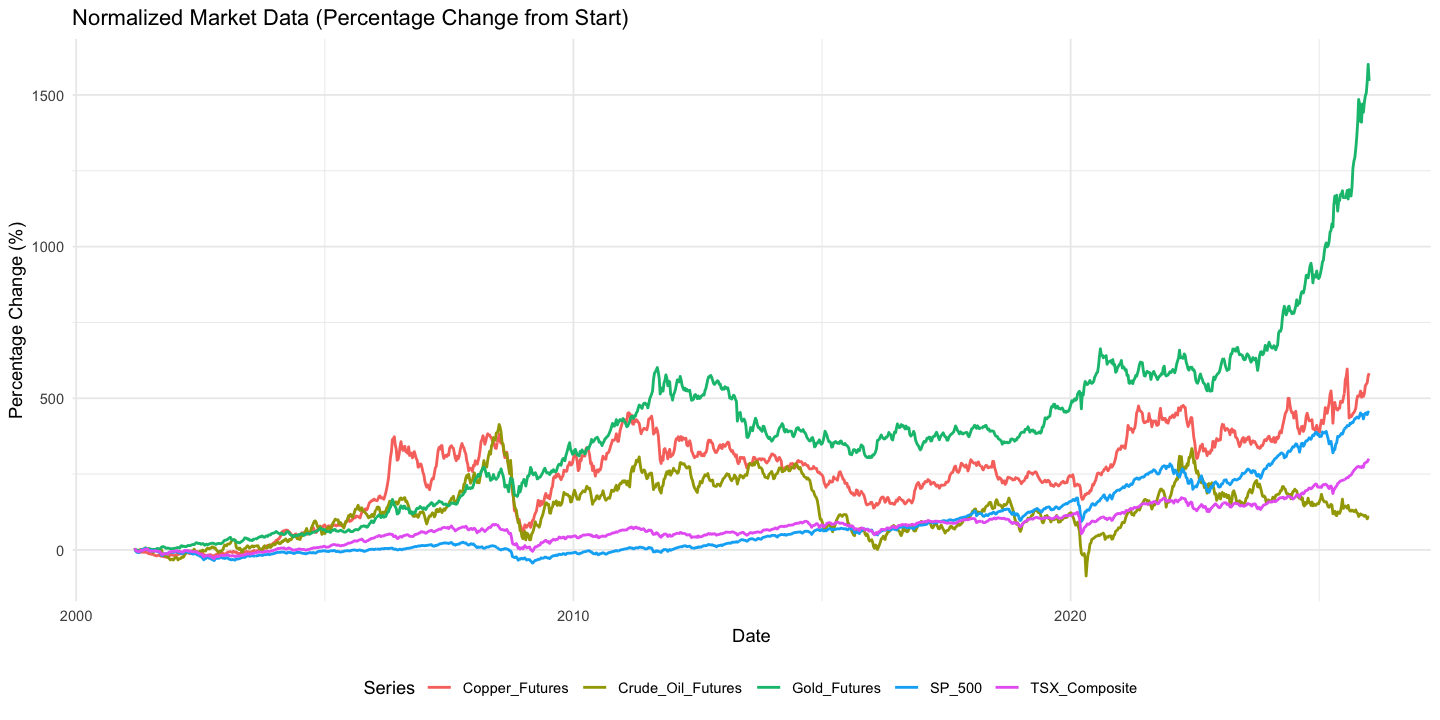

In [86]:
# close_data <- get_markets_data("2007-01-01", "2025-09-01", "weeks", plot=TRUE)

close_data <- get_markets_data("2001-03-01", "2026-01-01", "weeks", plot=FALSE)

close_data <- close_data %>%
  select(Date, 
    TSX_Composite, Crude_Oil_Futures,
    Gold_Futures, Copper_Futures, SP_500
    # Canada_Financials_Index,
    # USD_to_CAD, Canada_Corporate_Bonds,
    # Canada_Government_Bonds, US_oil_gas, Global_Materials,
    # US_Real_Estate
  )

# Normalize data as percentage change from first value
close_data_normalized <- close_data %>%
  mutate(across(-Date, ~ (. / first(.) - 1) * 100))

# Reshape for plotting
close_data_long <- close_data_normalized %>%
  pivot_longer(cols = -Date, names_to = "Series", values_to = "Percentage_Change")

# Plot
options(repr.plot.width=12, repr.plot.height=6)
ggplot(close_data_long, aes(x = Date, y = Percentage_Change, color = Series)) +
  geom_line(size = 0.8) +
  labs(title = "Normalized Market Data (Percentage Change from Start)",
        x = "Date",
        y = "Percentage Change (%)") +
  theme_minimal() +
  theme(legend.position = "bottom")



## Plot 1. General TSX 2001 - 2026

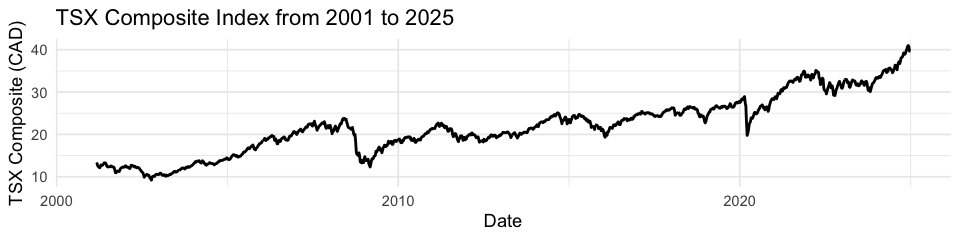

In [87]:
# Plot
options(repr.plot.width=8, repr.plot.height=2)
close_data_2025 <- close_data %>% filter(Date <= as.Date("2025-01-01"))
ggplot(close_data_2025, aes(x = Date, y = TSX_Composite)) +
  geom_line(size = 0.8) +
  labs(title = "TSX Composite Index from 2001 to 2025",
        x = "Date",
        y = "TSX Composite (CAD)") +
  theme_minimal() +
  theme(legend.position = "bottom")

In [88]:
## Plot 2. Fit an HMM on the full timeseries
close_data_log_2025 <- ln_transform(close_data_2025)

n_states <- 3
fitting_data <- close_data_log_2025 %>% select(TSX_Composite)
forecast_horizon <- 10

tsx_forecast <- fit_hmm(
    n_states = n_states,
    data = fitting_data,
    obs_name = "TSX_Composite",
    hid_formula = as.formula("~1"),
    horseshoe = FALSE,
    init = NULL
)
forecaster <- Forecast$new(
  hmm = tsx_forecast,
  n = forecast_horizon,
  preset_eval_range = list(TSX_Composite = seq(from=-0.15, to=0.15, by=0.001))
)



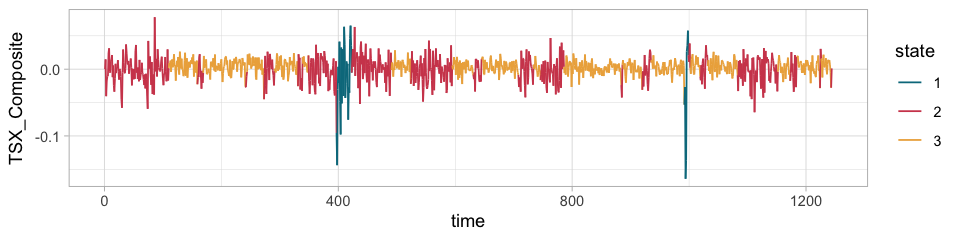

In [89]:
tsx_forecast$plot_ts('TSX_Composite')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for linetype is already present.
Adding another scale for linetype, which will replace the existing scale.


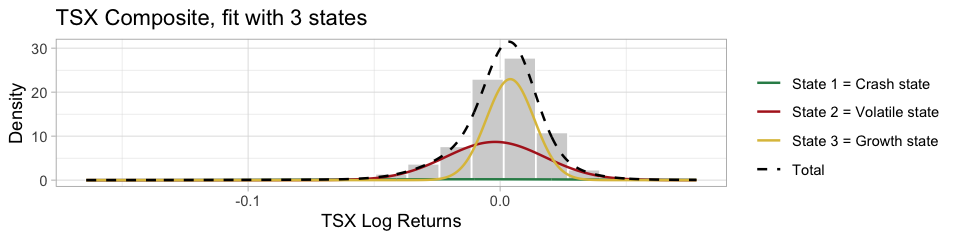

In [90]:
state_breaks <- c("State 1", "State 2", "State 3", "Total")
state_labels <- c("State 1 = Crash state", "State 2 = Volatile state", "State 3 = Growth state", "Total")
state_colors <- c("State 1" = "#2E8B57", "State 2" = "#B22222", "State 3" = "#dec04a", "Total" = "black")
state_linetypes <- c("State 1" = "solid", "State 2" = "solid", "State 3" = "solid", "Total" = "dashed")

plt <- tsx_forecast$plot_dist("TSX_Composite") +
labs(
title = "TSX Composite, fit with 3 states",
x = "TSX Log Returns",
y = "Density"
) +
scale_color_manual(
name = "",
breaks = state_breaks,
labels = state_labels,
values = state_colors
) +
scale_linetype_manual(
name = "",
breaks = state_breaks,
labels = state_labels,
values = state_linetypes
)

plt

In [91]:
names(plt)

NULL

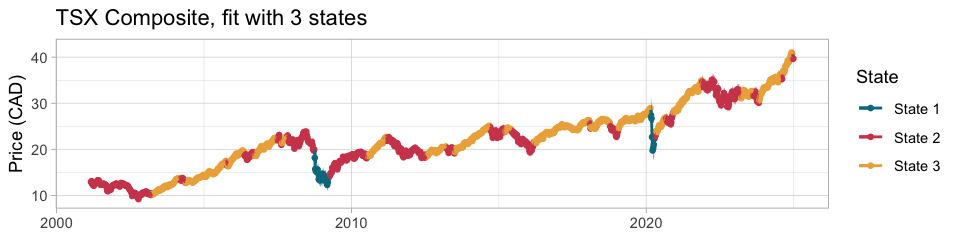

In [92]:
options(repr.plot.width=8, repr.plot.height=2)
# theme_set(
#   theme_minimal(base_size = 24) +
#     theme(
#       plot.title = element_text(size = 42, face = "bold"),
#       axis.title = element_text(size = 18),
#       axis.text = element_text(size = 14),
#       legend.title = element_text(size = 16),
#       legend.text = element_text(size = 14)
#     )
# )

close_data_2025 <- close_data %>% filter(Date <= as.Date("2025-01-01"))

close_data_indexed <- close_data_2025 %>% tibble::column_to_rownames("Date")
tsx_state_3s <- prepare_tsx_state_data(close_data_indexed, tsx_forecast) %>%
  mutate(
    State = recode(as.character(State),
      `1` = "State 1",
      `2` = "State 2",
      `3` = "State 3"
    ),
    State = factor(State, levels = c("State 1", "State 2", "State 3"))
  )
tsx_plot_3s  <- plot_tsx_state_series(tsx_state_3s, show = "both") +
  ggtitle(paste0("TSX Composite, fit with 3 states"))+
  xlim(as.Date("2001-03-01"), as.Date("2025-01-01"))

tsx_plot_3s

## Further Stuff

In [93]:
buffer <- 3
forecast_horizon <- 10

close_data_log <- ln_transform(close_data)

test_start_date <- as.Date("2019-11-01")
test_start_index <- which.min(abs(as.numeric(close_data$Date - test_start_date)))
test_end_index <- nrow(close_data_log) - buffer
test_size <- test_end_index - test_start_index - forecast_horizon

train_end_index <- as.integer(test_start_index*0.75)
train_end_date <- close_data$Date[train_end_index]

valid_size <- test_start_index - train_end_index - forecast_horizon

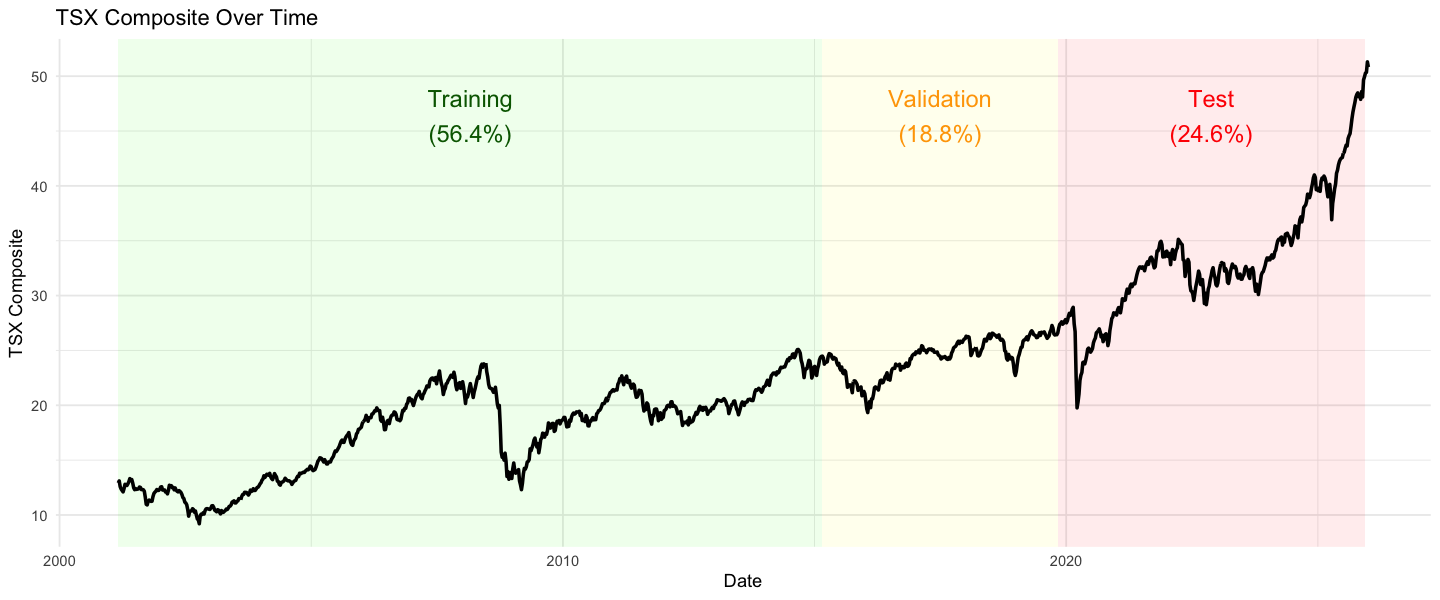

In [94]:
options(repr.plot.width=12, repr.plot.height=5)
ggplot(close_data, aes(x = Date, y = TSX_Composite)) +
  # Highlight train, validation, and test periods
  annotate("rect", xmin = min(close_data$Date), xmax = close_data$Date[train_end_index], ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "green") +
  annotate("rect", xmin = close_data$Date[train_end_index], xmax = close_data$Date[test_start_index], ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "yellow") +
  annotate("rect", xmin = close_data$Date[test_start_index], xmax = close_data$Date[test_end_index], ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "red") +
  geom_line(color = "black", size = 1) +
  labs(title = "TSX Composite Over Time", x = "Date", y = "TSX Composite") +
  theme_minimal() +
  annotate("text", 
           x = close_data$Date[round(train_end_index/2)], 
           y = Inf, 
           label = sprintf("Training\n(%.1f%%)", 100 * train_end_index / nrow(close_data)), 
           vjust = 2, size = 5, color = "darkgreen") +
  annotate("text", 
           x = close_data$Date[round((train_end_index + test_start_index)/2)], 
           y = Inf, 
           label = sprintf("Validation\n(%.1f%%)", 100 * (test_start_index - train_end_index) / nrow(close_data)), 
           vjust = 2, size = 5, color = "orange") +
  annotate("text", 
           x = close_data$Date[round((test_start_index + test_end_index)/2)], 
           y = Inf, 
           label = sprintf("Test\n(%.1f%%)", 100 * (test_end_index - test_start_index) / nrow(close_data)), 
           vjust = 2, size = 5, color = "red")


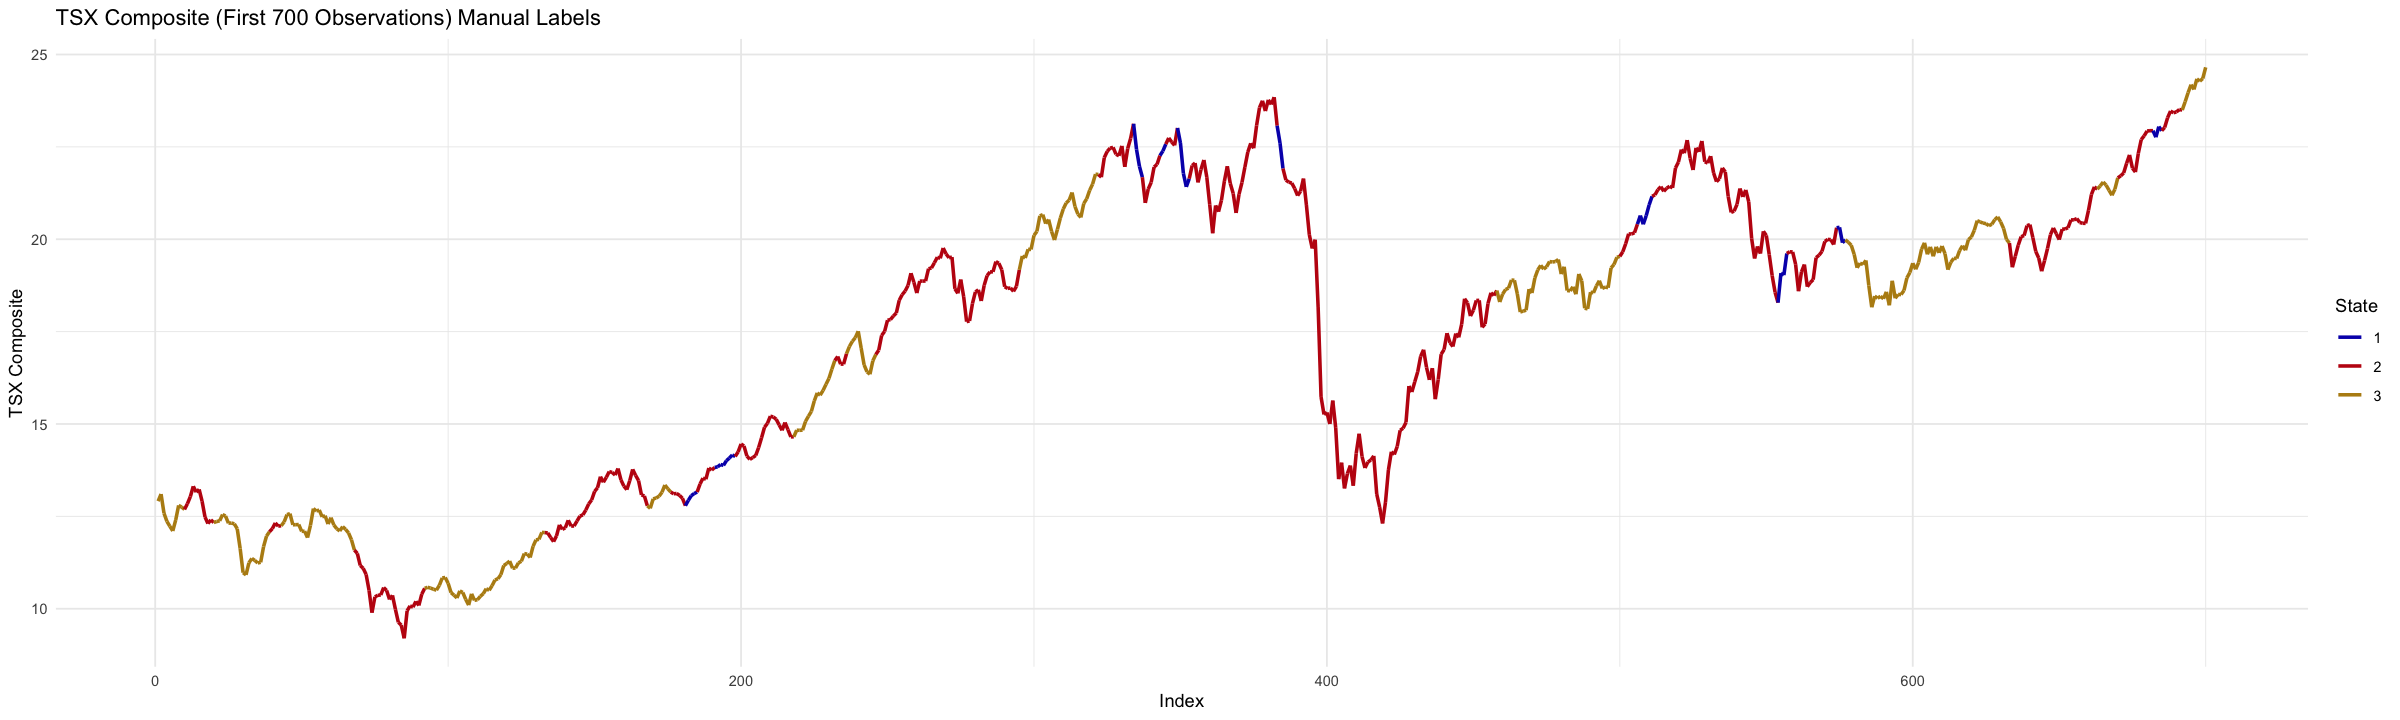

In [95]:
options(repr.plot.width=20, repr.plot.height=6)
# Start date must be 2005-01-01 to use manually labeled states
state_array <- c(
  3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, # 35
  3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, # 70
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, # 105
  3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, # 140
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, # 175
  2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, # 210
  2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, # 245
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, # 280
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, # 315
  3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 1, # 350
  1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, # 385
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, # 420
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, # 455
  2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, # 490
  3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, # 525
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, # 560
  2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, # 595
  3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, # 630
  3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, # 665
  3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3 # 700
)
# Create a data frame for plotting
plot_df <- data.frame(Index = 1:700, TSX_Composite = close_data$TSX_Composite[1:700], State = as.factor(state_array))
ggplot(plot_df, aes(Index, TSX_Composite, color = State, group = 1)) +
  geom_line(size = 1) +
  scale_color_manual(values = c("1" = "#0b0eb9", "2" = "#c11b12", "3" = "#b78c14")) +
  labs(title = "TSX Composite (First 700 Observations) Manual Labels", x = "Index", y = "TSX Composite", color = "State") +
  theme_minimal() + 
  xlim(1, 700)



### For each step of the test set, do a one step forecast and get the state probabilites

In [96]:
cross_entropy_loss <- function(y_true, y_hat) {
  # Add small epsilon to avoid log(0)
  epsilon <- 1e-12
  y_hat <- pmax(pmin(y_hat, 1 - epsilon), epsilon)
  array(-rowSums(y_true * log(y_hat)))
}

In [97]:
forecast_horizon <- 10
n_states <- 3
use_fixed_params <- FALSE
use_supervised_states <- FALSE
apply_winzorization <- FALSE
obs_name <- 'TSX_Composite'
model_name <- paste0(
  n_states, " state model",
  ifelse(use_fixed_params, ", Fixed Parameters", ""),
  ifelse(use_supervised_states, ", Supervised", ""),
  ifelse(apply_winzorization, ", Winzorized", "")
)

if (apply_winzorization) {
  close_data_log$TSX_Composite <- pmax(close_data_log$TSX_Composite, -0.055)
  close_data_log$TSX_Composite <- pmin(close_data_log$TSX_Composite, 0.055)
}

tsx_training_data <- close_data_log[1:train_end_index, , drop = FALSE]
if (use_supervised_states) {
  extended_state_array <- rep(NA, nrow(tsx_training_data))
  extended_state_array[1:min(length(state_array), nrow(tsx_training_data))] <- state_array[1:min(length(state_array), nrow(tsx_training_data))]
  tsx_training_data$state <- extended_state_array
}

if (n_states == 3 && use_fixed_params) {
  pars <- setNames(
    list(
      list(
        mean = c(-0.025, 0.00, 0.015),
        sd = c(0.03, 0.02, 0.02)
      )
    ),
    obs_name
  )
  fixpar <- list(obs = c(
      "TSX_Composite.mean.state1.(Intercept)" = NA,
      "TSX_Composite.mean.state2.(Intercept)" = NA,
      "TSX_Composite.mean.state3.(Intercept)" = NA
      )
  )
} else {
  pars <- setNames(
    list(
      list(
        mean = seq(-0.02, 0.01, length.out = n_states),
        sd = seq(0.1, 0.01, length.out = n_states)
      )
    ),
    obs_name
  )
  fixpar <- list()
}

hid_model <- MarkovChain$new(
  data = tsx_training_data,
  n_states = n_states,
  initial_state = "estimated"
)

obs_model <- Observation$new(
  data = tsx_training_data,
  n_states = n_states,
  dists = setNames(list("norm"), obs_name),
  par = pars
)
training_model <- HMM$new(hid = hid_model, obs = obs_model, fixpar = fixpar)
training_model$fit(silent = TRUE)

full_model <- fit_hmm(
  n_states = n_states,
  data = close_data_log,
  obs_name = "TSX_Composite",
  hid_formula = as.formula("~1"),
  horseshoe = FALSE,
  init = training_model
)
true_state_probs <- full_model$state_probs()

state_losses <- matrix(NA, nrow = test_size, ncol = forecast_horizon)
predictions <- array(NA, dim = c(test_size, forecast_horizon, n_states))
ground_truth <- array(NA, dim = c(test_size, forecast_horizon, n_states))

j <- 1
for (i in ((test_start_index+1):(test_end_index-forecast_horizon))) {
  fitting_data <- close_data_log[(i-100):i, , drop = FALSE]
  Y_true <- true_state_probs[(i+1):(i+forecast_horizon), , drop = FALSE]
  tsx_forecast <- fit_hmm(
    n_states = n_states,
    data = fitting_data,
    obs_name = "TSX_Composite",
    hid_formula = as.formula("~1"),
    horseshoe = FALSE,
    init = training_model
  )
  forecaster <- Forecast$new(
    hmm = tsx_forecast,
    n = forecast_horizon,
    preset_eval_range = list(TSX_Composite = seq(from=-0.15, to=0.15, by=0.001))
  )
  Y_hat <- t(forecaster$hidden_state_forecast())
  predictions[j, , ] <- Y_hat
  ground_truth[j, , ] <- Y_true
  loss <- cross_entropy_loss(
    Y_true,
    Y_hat
  )
  state_losses[j, ] <- loss
  j <- j + 1
}

valid_loss <- matrix(NA, nrow = valid_size, ncol = forecast_horizon)

j <- 1
for (i in ((train_end_index+1):(test_start_index-forecast_horizon))) {
  fitting_data <- close_data_log[(i-100):(i-forecast_horizon), , drop = FALSE]
  Y_true <- true_state_probs[(i+1):(i+forecast_horizon), , drop = FALSE]
  tsx_forecast <- fit_hmm(
    n_states = n_states,
    data = fitting_data,
    obs_name = "TSX_Composite",
    hid_formula = as.formula("~1"),
    horseshoe = FALSE,
    init = training_model
  )
  forecaster <- Forecast$new(
    hmm = tsx_forecast,
    n = forecast_horizon,
    preset_eval_range = list(TSX_Composite = seq(from=-0.15, to=0.15, by=0.001))
  )
  Y_hat <- t(forecaster$hidden_state_forecast())
  loss <- cross_entropy_loss(
    Y_true,
    Y_hat
  )
  valid_loss[j, ] <- loss
  j <- j + 1
}

In [98]:
close_data_pct <- close_data_indexed %>%
  mutate(across(everything(), ~ (. / first(.) - 1) * 100))

close_data_pct

,TSX_Composite,Crude_Oil_Futures,Gold_Futures,Copper_Futures,SP_500
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2001-03-02,0.000000000,0.0000000,0.00000000,0.000000,0.00000000
2001-03-09,1.481117042,2.4617048,0.13274596,1.087814,1.24974960
2001-03-16,-2.540460949,-2.5049541,0.05689013,-2.218170,-5.17062091
2001-03-23,-4.247183003,-4.3431253,-1.02029642,-4.478881,-8.23737871
2001-03-30,-5.267291513,-3.2546407,-1.43751620,-6.204801,-6.29547418
2001-04-06,-6.248166103,-3.9682813,-2.22644042,-7.942876,-9.14306386
2001-04-13,-3.948011991,1.1443508,-1.91542215,-7.414160,-5.96873562
2001-04-20,-0.892594947,0.9839630,-0.18585916,-6.314190,-1.53337829
2001-04-27,-1.226092869,-0.1838142,0.01896106,-7.687631,-0.65025581


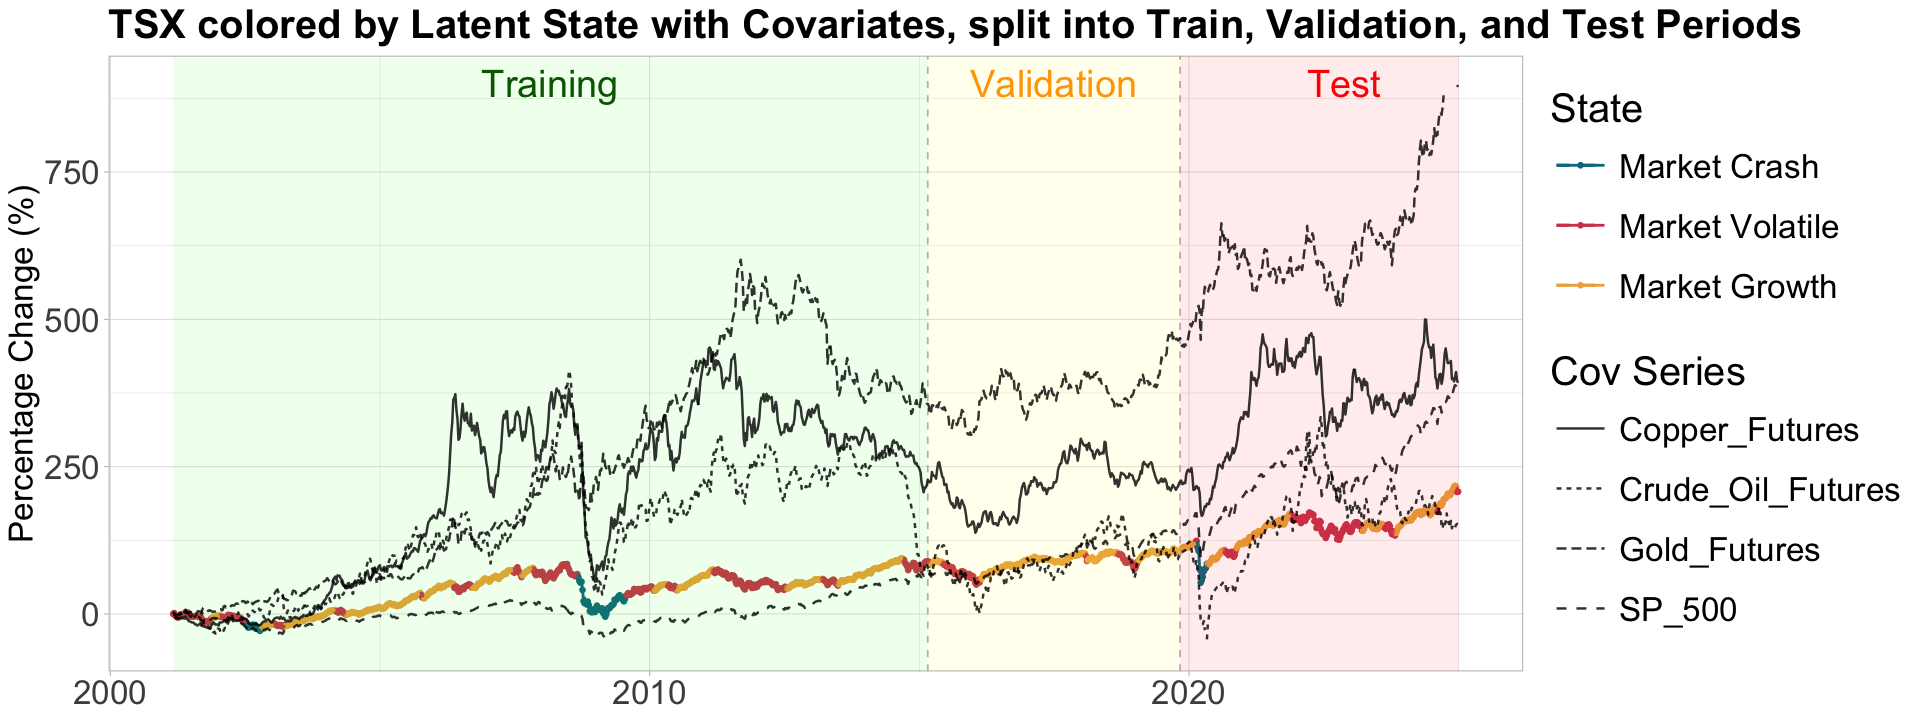

In [99]:
options(repr.plot.width=16, repr.plot.height=6)
theme_set(
  theme_minimal(base_size = 24) +
    theme(
      plot.title = element_text(size = 42, face = "bold"),
      axis.title = element_text(size = 18),
      axis.text = element_text(size = 14),
      legend.title = element_text(size = 16),
      legend.text = element_text(size = 14)
    )
)

close_data_indexed <- close_data %>% tibble::column_to_rownames("Date")
close_data_pct <- close_data_indexed %>%
  mutate(across(everything(), ~ (. / first(.) - 1) * 100))
tsx_state_3s <- prepare_tsx_state_data(close_data_pct, full_model) %>%
  mutate(
    State = recode(as.character(State),
      `1` = "Market Crash",
      `2` = "Market Volatile",
      `3` = "Market Growth"
    ),
    State = factor(State, levels = c("Market Crash", "Market Volatile", "Market Growth"))
  )
tsx_plot_3s  <- plot_tsx_state_series(tsx_state_3s, show = "both") +
  ggtitle(paste0("TSX Composite, ", model_name))+
  xlim(as.Date("2001-03-01"), as.Date("2025-01-01"))
#   xlim(as.Date("2005-01-01"), as.Date("2010-01-01"))

train_start_date <- close_data$Date[1]
train_mid_date <- close_data$Date[round(train_end_index/2)]
train_end_date <- close_data$Date[train_end_index]
valid_mid_date <- close_data$Date[round((train_end_index + test_start_index)/2)]
test_start_date <- close_data$Date[test_start_index]
test_mid_date <- close_data$Date[round((test_start_index + test_end_index)/2)]
test_end_date <- as.Date("2025-01-01") #close_data$Date[test_end_index]

tsx_plot_3s <- tsx_plot_3s + 
  geom_vline(xintercept = train_end_date, linetype = "dashed", color = "grey") +
  geom_vline(xintercept = test_start_date, linetype = "dashed", color = "grey") +
  annotate("rect", xmin = train_start_date, xmax = train_end_date, ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "green") +
  annotate("rect", xmin = train_end_date, xmax = test_start_date, ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "yellow") +
  annotate("rect", xmin = test_start_date, xmax = test_end_date, ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "red") +
  annotate("text", x = train_mid_date, y = Inf, label = "Training", vjust = 1.5, size = 8, color = "darkgreen") +
  annotate("text", x = valid_mid_date, y = Inf, label = "Validation", vjust = 1.5, size = 8, color = "orange") +
  annotate("text", x = test_mid_date, y = Inf, label = "Test", vjust = 1.5, size = 8, color = "red") +
  ggtitle("TSX colored by Latent State with Covariates, split into Train, Validation, and Test Periods")

tsx_plot_3s <- tsx_plot_3s +
  theme(
    plot.title = element_text(size = 24, face = "bold"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    legend.text = element_text(size = 20),
    legend.position = "right",
    legend.key.size = unit(2.5, "lines"),

  )

tsx_plot_3s <- tsx_plot_3s + 
  geom_line(
    data = tibble::rownames_to_column(close_data_pct, "Date") %>%
      mutate(Date = as.Date(Date)) %>%
      select(Date, Crude_Oil_Futures, Gold_Futures, Copper_Futures, SP_500) %>%
      pivot_longer(
        cols = -Date,
        names_to = "Cov Series",
        values_to = "Value"
      ),
    aes(x = Date, y = Value, group = `Cov Series`, linetype = `Cov Series`),
    inherit.aes = FALSE,
    linewidth = 0.7,
    alpha = 0.8
  )

tsx_plot_3s + ylim(-50, 900) + ylab("Percentage Change (%)")


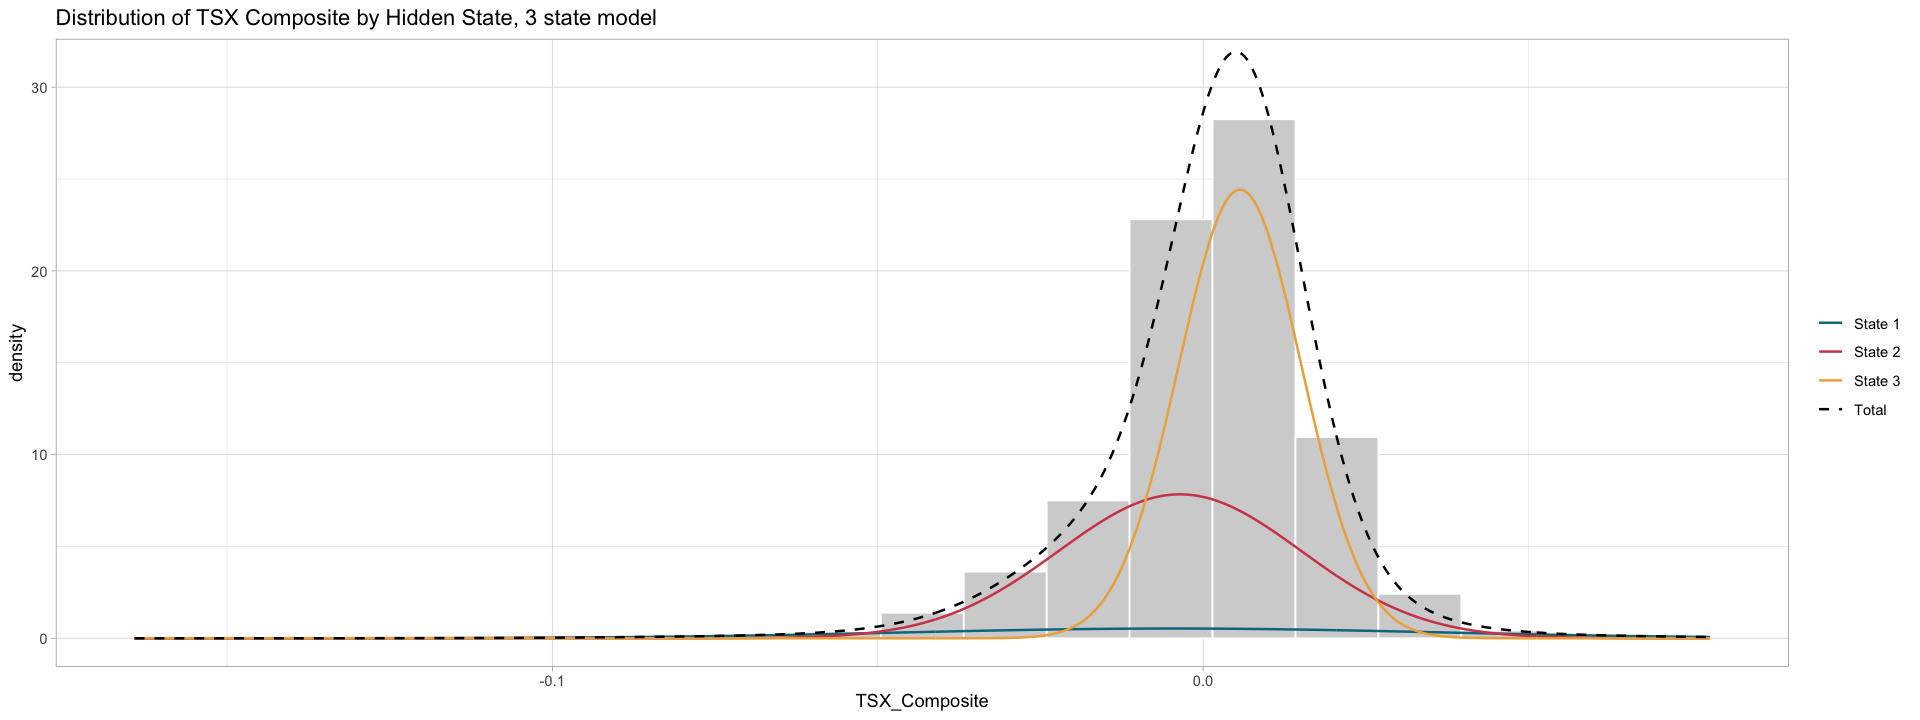

In [100]:
full_model$plot_dist('TSX_Composite') +
  ggtitle(paste0("Distribution of TSX Composite by Hidden State, ", model_name))

In [101]:
full_model$hid()$tpm()

, , 1

             state 1    state 2    state 3
state 1 9.608782e-01 0.02515124 0.01397054
state 2 8.058041e-03 0.89333081 0.09861115
state 3 1.855656e-07 0.08550071 0.91449910

In [102]:
states <- full_model$states()
state_factor <- as.factor(states)
state_table <- table(state_factor)
state_percent <- prop.table(state_table) * 100

# Calculate durations
rle_states <- rle(states)
durations <- data.frame(state = rle_states$values, length = rle_states$lengths)

summary_df <- durations %>%
  group_by(state) %>%
  summarise(
    periods = n(),
    avg_duration = mean(length),
    min_duration = min(length),
    max_duration = max(length)
  )

summary_df$state_percent <- as.numeric(state_percent)
summary_df

state,periods,avg_duration,min_duration,max_duration,state_percent
<int>,<int>,<dbl>,<int>,<int>,<dbl>
1,3,23.66667,10,47,5.474171
2,22,21.59091,1,71,36.622976
3,21,35.76190,8,101,57.902853


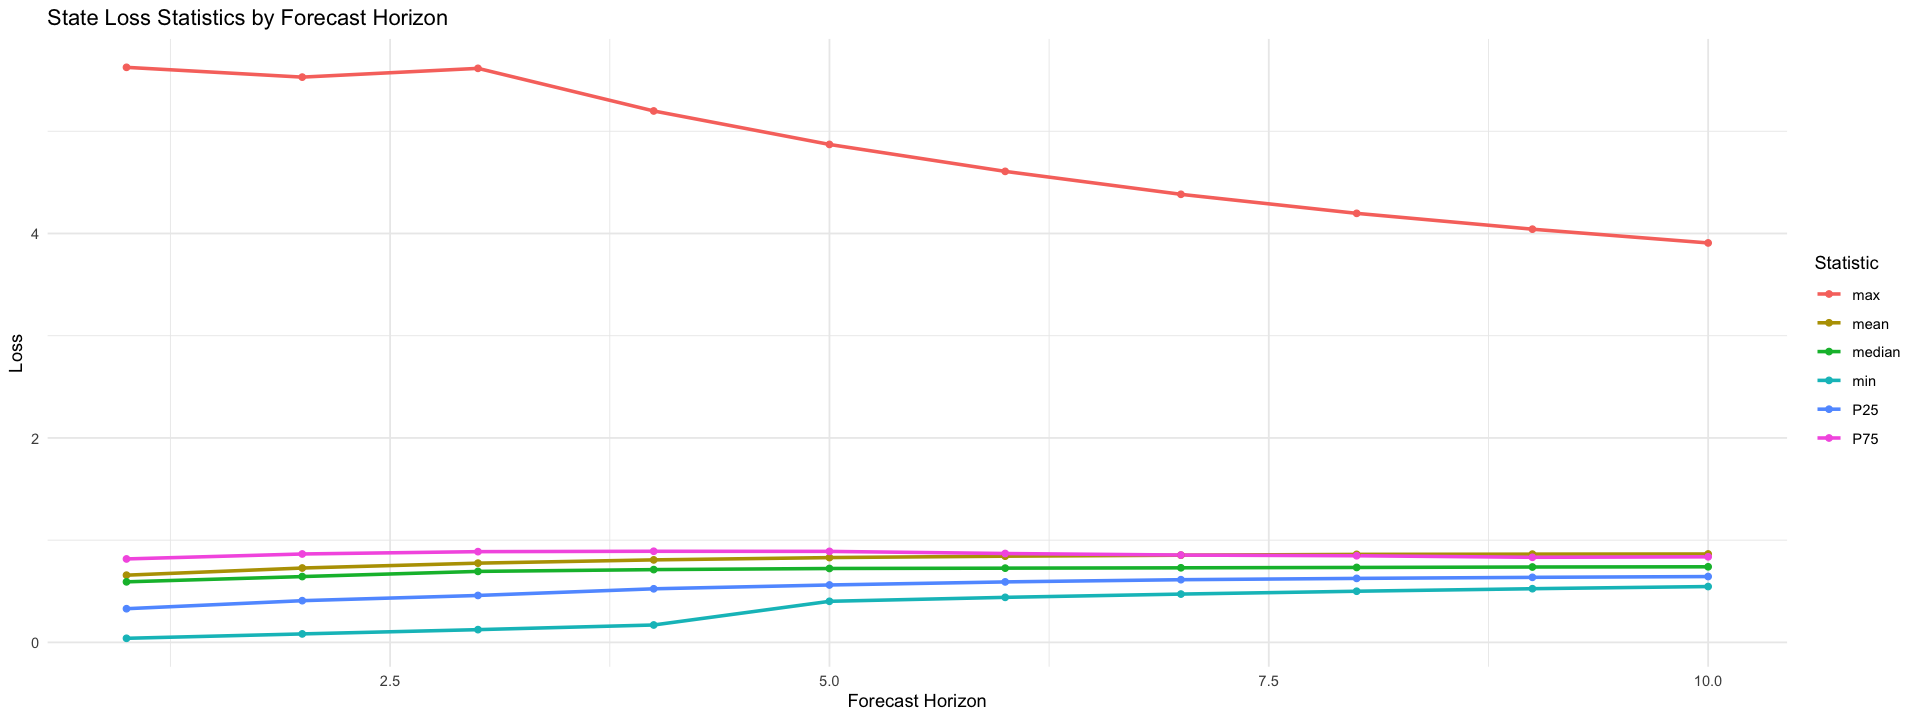

In [103]:
# Compute statistics for each forecast horizon (column)
stats_df <- data.frame(
  Horizon = 1:ncol(state_losses),
  mean = apply(state_losses, 2, mean, na.rm = FALSE),
  median = apply(state_losses, 2, median, na.rm = FALSE),
  P25 = apply(state_losses, 2, quantile, probs = 0.25, na.rm = FALSE),
  P75 = apply(state_losses, 2, quantile, probs = 0.75, na.rm = FALSE),
  max = apply(state_losses, 2, max, na.rm = FALSE),
  min = apply(state_losses, 2, min, na.rm = FALSE)
)

# Reshape for plotting
library(tidyr)
stats_long <- pivot_longer(stats_df, cols = -Horizon, names_to = "Statistic", values_to = "Value")

# Plot
library(ggplot2)
ggplot(stats_long, aes(x = Horizon, y = Value, color = Statistic)) +
  geom_line(size = 1) +
  geom_point() +
  labs(title = "State Loss Statistics by Forecast Horizon",
       x = "Forecast Horizon",
       y = "Loss") +
  theme_minimal()

In [104]:
stats_df

Horizon,mean,median,P25,P75,max,min
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.6575026,0.5923819,0.3294191,0.8163796,5.625403,0.03990760
2,0.7275328,0.6440004,0.4081085,0.8648809,5.529632,0.08300096
3,0.7751658,0.6945197,0.4590954,0.8875983,5.615519,0.12480230
4,0.8070867,0.7121053,0.5242471,0.8914726,5.198633,0.17023298
5,0.8297362,0.7229837,0.5616105,0.8902793,4.871166,0.40183591
6,0.8432259,0.7263301,0.5917693,0.8694852,4.607662,0.44059791
7,0.8530075,0.7296830,0.6132697,0.8545956,4.383337,0.47259933
8,0.8609648,0.7330790,0.6260518,0.8474712,4.197042,0.50050553
9,0.8634140,0.7373511,0.6363821,0.8323243,4.042137,0.52525336


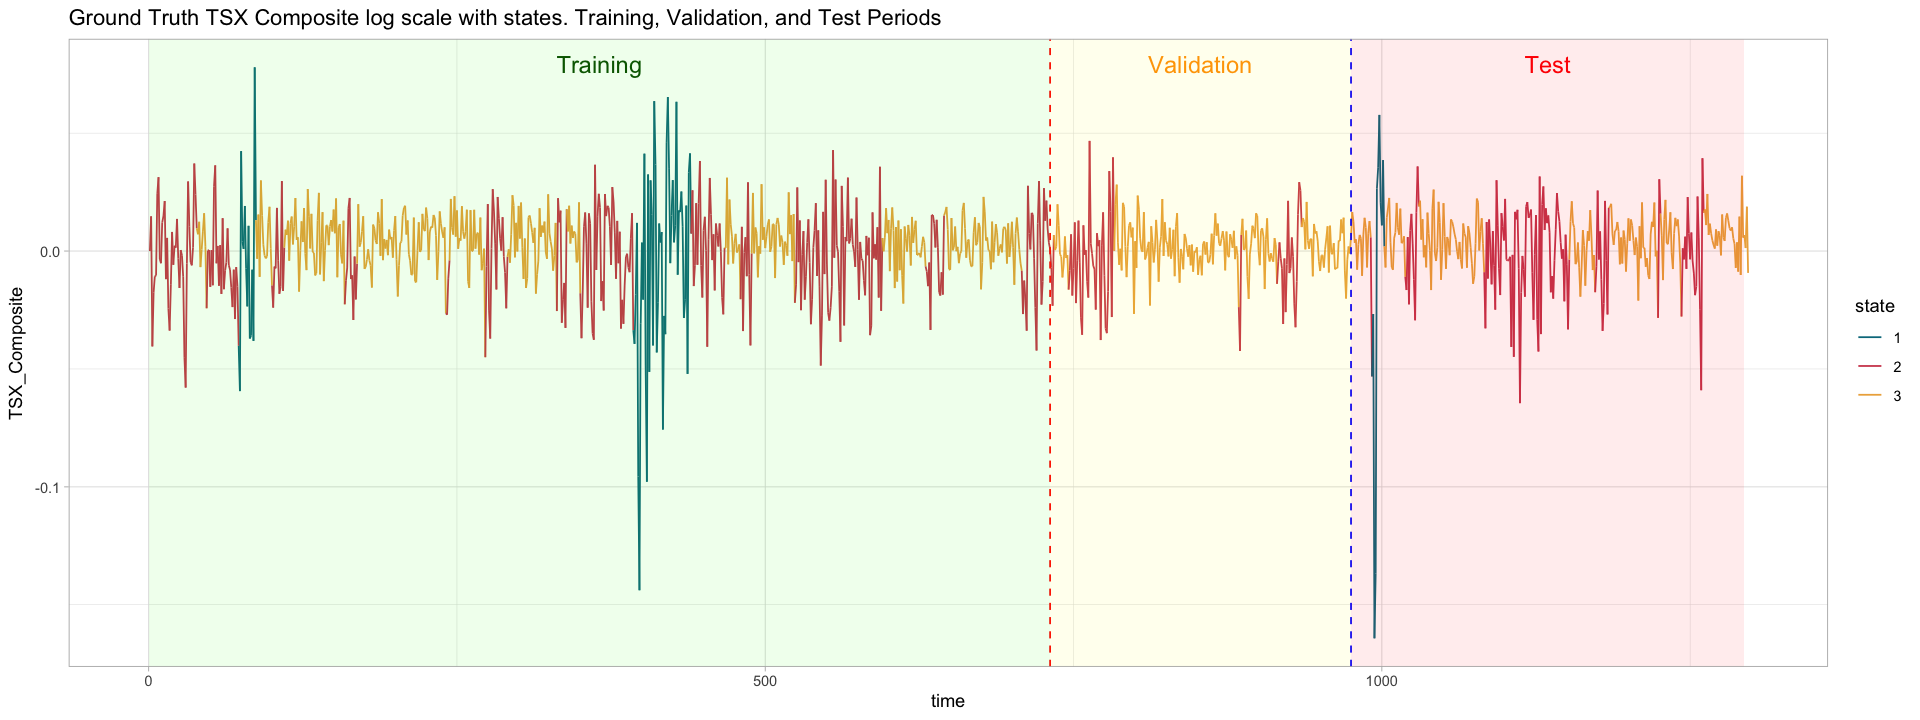

In [105]:
options(repr.plot.width=16, repr.plot.height=6)

p <- full_model$plot_ts("TSX_Composite")

p + 
  geom_vline(xintercept = train_end_index, linetype = "dashed", color = "red") +
  geom_vline(xintercept = test_start_index, linetype = "dashed", color = "blue") +
  annotate("rect", xmin = 0, xmax = train_end_index, ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "green") +
  annotate("rect", xmin = train_end_index, xmax = test_start_index, ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "yellow") +
  annotate("rect", xmin = test_start_index, xmax = test_end_index, ymin = -Inf, ymax = Inf, alpha = 0.08, fill = "red") +
  annotate("text", x = train_end_index/2, y = Inf, label = "Training", vjust = 2, size = 5, color = "darkgreen") +
  annotate("text", x = (train_end_index + test_start_index)/2, y = Inf, label = "Validation", vjust = 2, size = 5, color = "orange") +
  annotate("text", x = (test_start_index + test_end_index)/2, y = Inf, label = "Test", vjust = 2, size = 5, color = "red") +
  ggtitle("Ground Truth TSX Composite log scale with states. Training, Validation, and Test Periods")

## Create the training, validation and test sets needed by LSTM model

In [106]:
# Train base models for covariate columns
covariates <- c("TSX_Composite", "Crude_Oil_Futures", "Gold_Futures", "Copper_Futures",  "SP_500")
lookback <- 10
hmm_lookback <- 50

trained_models <- list(TSX_Composite = training_model)
for (covariate in setdiff(covariates, "TSX_Composite")) {
  # Exclude TSX Composite to avoid risk of states being label swaped.
  hmm_model <- fit_hmm(
    n_states = n_states,
    data = close_data_log[1:train_end_index, , drop = FALSE],
    obs_name = covariate,
    hid_formula = as.formula("~1"),
    horseshoe = FALSE,
    init = NULL
  )
  trained_models[[covariate]] <- hmm_model
}

# Define the function to prepare X and Y lists for a given index range
prepare_dataset <- function(start_idx, end_idx) {
  num_samples <- end_idx - start_idx + 1 - forecast_horizon
  n_cov <- length(covariates)
  features <- n_cov * (n_states + 1) # n_states + 1 log return per covariate

  X <- array(NA, dim = c(num_samples, lookback, features))
  Y <- array(NA, dim = c(num_samples, forecast_horizon, n_states))

  j <- 1
  for (i in start_idx:(end_idx-forecast_horizon)) {
    fitting_data <- close_data_log[(i - hmm_lookback):i, , drop = FALSE]
    training_data <- array(NA, dim = c(lookback, 0))
    for (covariate in covariates) {
      cov_model <- fit_hmm(
        n_states = n_states,
        data = fitting_data,
        obs_name = covariate,
        hid_formula = as.formula("~1"),
        horseshoe = FALSE,
        init = trained_models[[covariate]]
      )
      states <- tail(cov_model$state_probs(), lookback)
      colnames(states) <- paste0(covariate, "_", 1:n_states)
      log_data <- tail(fitting_data[, covariate, drop = FALSE], lookback)
      training_data <- cbind(training_data, as.matrix(states), as.matrix(log_data))
    }
    Y_data <- true_state_probs[(i + 1):(i + forecast_horizon), , drop = FALSE]
    X[j, , ] <- training_data
    Y[j, , ] <- Y_data
    j <- j + 1
  }
  return(list(X = X, Y = Y))
}

# Call the function for training data
train_data <- prepare_dataset(hmm_lookback, train_end_index)
X_train <- train_data$X
Y_train <- train_data$Y

# Call the function for validation data
valid_data <- prepare_dataset(train_end_index + 1, test_start_index)
X_valid <- valid_data$X
Y_valid <- valid_data$Y

# Call the function for test data
test_data <- prepare_dataset(test_start_index + 1, test_end_index)
X_test <- test_data$X
Y_test <- test_data$Y

In [107]:
full_model$par()$obspar

, , 1

                        state 1     state 2     state 3
TSX_Composite.mean -0.004533925 -0.00356220 0.005669056
TSX_Composite.sd    0.041020426  0.01864314 0.009458915

In [108]:
folder_name <- model_name %>%
  gsub(", ", "_", .) %>%
  gsub(" ", "_", .) %>%
  tolower()
if (!dir.exists(folder_name)) {
  dir.create(folder_name)
}

tpm <- full_model$hid()$tpm()
obspar <- full_model$par()$obspar

In [109]:
1294 - 50

[1] 1244

In [110]:
hmm_lookback

[1] 50

In [111]:
test_end_index

[1] 1294

In [113]:
#write.csv(close_data_log[0:test_end_index], paste0(folder_name, "/close_data_log.csv"), row.names = FALSE)
write.csv(tpm, paste0(folder_name, "/transition_matrix.csv"), row.names = TRUE)
write.csv(obspar, paste0(folder_name, "/obspar.csv"), row.names = TRUE)
saveRDS(X_train, paste0(folder_name, "/lstm_X_train.rds"))
saveRDS(Y_train, paste0(folder_name, "/lstm_Y_train.rds"))
saveRDS(X_valid, paste0(folder_name, "/lstm_X_valid.rds"))
saveRDS(Y_valid, paste0(folder_name, "/lstm_Y_valid.rds"))
saveRDS(X_test, paste0(folder_name, "/lstm_X_test.rds"))
saveRDS(Y_test, paste0(folder_name, "/lstm_Y_test.rds"))
saveRDS(stats_df, paste0(folder_name, "/hmm_stats_df.rds"))
saveRDS(state_losses, paste0(folder_name, "/hmm_state_losses.rds"))
saveRDS(predictions, paste0(folder_name, "/hmm_predictions.rds"))
saveRDS(ground_truth, paste0(folder_name, "/hmm_ground_truth.rds"))
saveRDS(valid_loss, paste0(folder_name, "/hmm_valid_loss.rds"))

In [ ]:
dim(X_train)

[1] 672  10  20

In [ ]:
dim(X_valid)

[1] 234  10  20

In [ ]:
dim(X_test)

[1] 309  10  20

In [ ]:
ground_truth[10, , ] == Y_test[10, , ]

TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE
TRUE,TRUE,TRUE


In [ ]:
dim(X_valid)

[1] 234  10  20

In [ ]:
dim(valid_loss)

[1] 234  10